### Explorative Spatial Data Analysis

This notebook performs an exploratory spatial data analysis of New York City neighborhoods. The 2010 Neighborhood Tabulation Areas (NTAs) GeoJSON dataset is loaded with GeoPandas, inspected, and visualized. Neighborhood area and perimeter values are converted to numeric types and examined using histograms with logarithmic scales.

The notebook then loads a borough boundary dataset, compares its coordinate reference system with the neighborhood data, and reprojects the neighborhoods to match the borough boundaries. The datasets are overlaid to identify the neighborhoods contained within each borough. Neighborhood counts are calculated using both grouping and spatial overlay, then compared using a correlation matrix.

Finally, the borough and neighborhood boundaries are plotted together to visually compare the two spatial datasets.

In [26]:
import geopandas as gpd
from pathlib import Path

In [27]:
file_path = Path("../data/2010 Neighborhood Tabulation Areas (NTAs).geojson")

In [28]:
gdf = gpd.read_file(file_path)
gdf.head()

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ..."
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ..."
3,BK68,16482821.6487,047,Fort Greene,19825.5208594,Brooklyn,3,"MULTIPOLYGON (((-73.96939 40.69608, -73.96938 ..."
4,QN38,38835920.1944,081,Pomonok-Flushing Heights-Hillcrest,30731.4196253,Queens,4,"MULTIPOLYGON (((-73.7964 40.73828, -73.79639 4..."


In [5]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

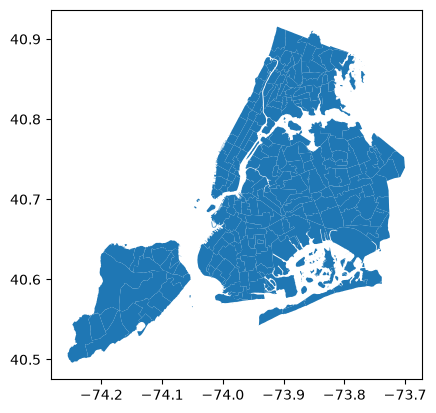

In [6]:
gdf.plot()

<Axes: >

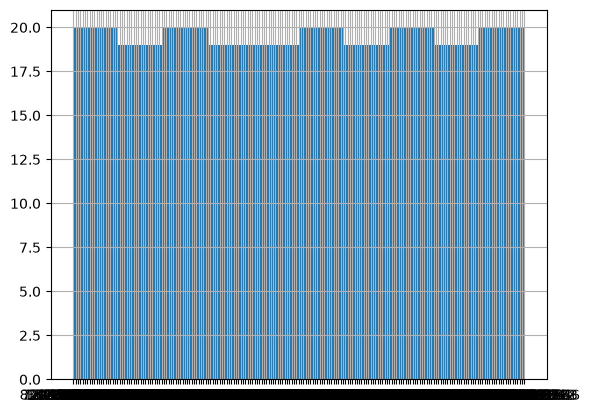

In [7]:
gdf.shape_area.hist()

In [10]:
print(type(gdf.shape_area.to_list()[0]))

<class 'str'>


In [11]:
gdf['shape_area'] = gdf['shape_area'].astype(float)
gdf['shape_leng'] = gdf['shape_leng'].astype(float)

In [13]:
print(type(gdf.shape_area.to_list()[0]))

<class 'float'>


Text(0.5, 1.0, 'NYC Neighborhood Area Shape Length')

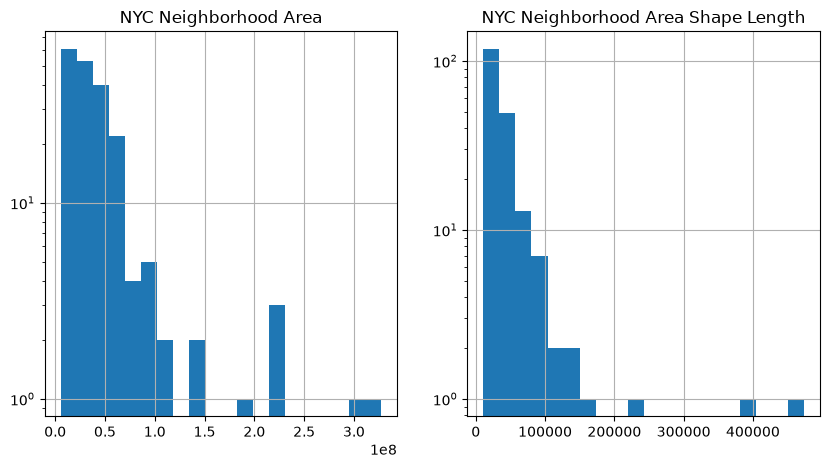

In [18]:
import matplotlib.pyplot as plt

f,ax = plt.subplots(1,2,figsize=(10,5))

gdf['shape_area'].hist(ax=ax[0], bins=20)
gdf['shape_leng'].hist(ax=ax[1], bins=20)

ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].set_title('NYC Neighborhood Area')
ax[1].set_title('NYC Neighborhood Area Shape Length')

#### Combine & compare spatial datasets

In [29]:
import geodatasets
from geodatasets import get_path

In [30]:
nybb = gpd.read_file(get_path('nybb'))
nybb.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


Text(0.5, 1.0, 'NYC Neighborhoods')

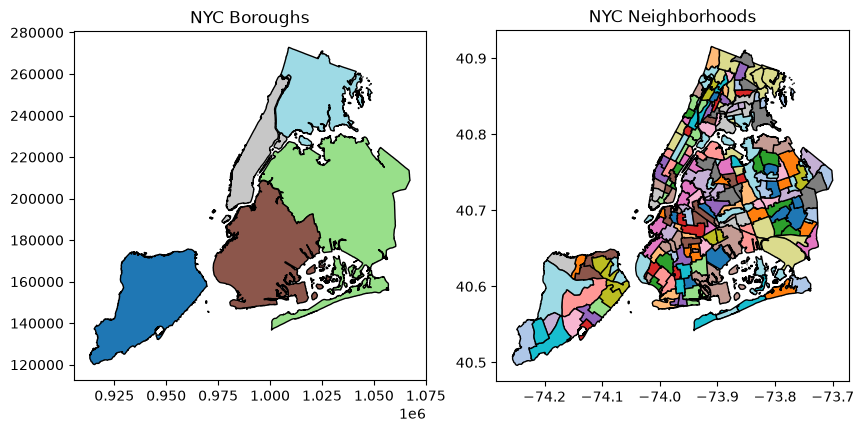

In [31]:
f,ax = plt.subplots(1,2,figsize=(10,5))

nybb.plot(ax=ax[0], cmap='tab20', edgecolor='black')
gdf.plot(ax=ax[1], cmap='tab20', edgecolor='black')

ax[0].set_title('NYC Boroughs')
ax[1].set_title('NYC Neighborhoods')

In [32]:
print(nybb.crs, gdf.crs)

EPSG:2263 EPSG:4326


In [33]:
gdf_local = gdf.to_crs(nybb.crs)
print(nybb.crs, gdf_local.crs)

EPSG:2263 EPSG:2263


In [35]:
gdf_local.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((1052996.114 196307.361, 105308..."
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((1015236.113 174910.103, 101523..."
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((1013128.551 250637.755, 101284..."


In [36]:
nybb.head(3)

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."


In [37]:
df_group_1 = gdf_local.groupby(by = 'boro_name').count()[['geometry']].rename(columns = {'geometry' : 'ngh_cnt_1'})
df_group_1

,ngh_cnt_1
boro_name,
Bronx,38
Brooklyn,51
Manhattan,29
Queens,58
Staten Island,19


In [38]:
gdf_over = gpd.overlay(nybb, gdf_local[['ntaname', 'geometry']])
gdf_over.head(3)

,BoroCode,BoroName,Shape_Leng,Shape_Area,ntaname,geometry
0,5,Staten Island,330470.010332,1.623820e+09,Charleston-Richmond Valley-Tottenville,"POLYGON ((922528.377 122455.996, 922528.29 122..."
1,5,Staten Island,330470.010332,1.623820e+09,Port Richmond,"MULTIPOLYGON (((944964.084 172610.981, 944984...."
2,5,Staten Island,330470.010332,1.623820e+09,New Dorp-Midland Beach,"POLYGON ((960370.525 147063.194, 960204.812 14..."


In [39]:
df_group_2 = gdf_over.groupby(by = 'BoroName').count()
df_group_2 = df_group_2[['ntaname']].rename(columns = {'ntaname' : 'ngh_cnt_2'})
df_group_2

,ngh_cnt_2
BoroName,
Bronx,39
Brooklyn,62
Manhattan,36
Queens,65
Staten Island,20


In [41]:
df_group = df_group_1.merge(df_group_2, left_index = True, right_index = True)
df_group

,ngh_cnt_1,ngh_cnt_2
boro_name,,
Bronx,38,39
Brooklyn,51,62
Manhattan,29,36
Queens,58,65
Staten Island,19,20


In [42]:
df_group.corr()

,ngh_cnt_1,ngh_cnt_2
ngh_cnt_1,1.000000,0.984094
ngh_cnt_2,0.984094,1.000000


<Axes: >

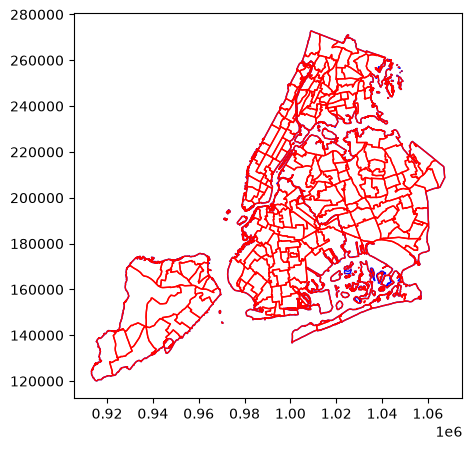

In [45]:
f,ax = plt.subplots(1,1,figsize=(10,5))
nybb.plot(ax=ax, color= 'None', edgecolor='blue')
gdf_local.plot(ax=ax, color= 'None', edgecolor='red')

In [47]:
print("Final insights:")
print(f"- The dataset contains {len(gdf)} NYC neighborhoods (NTAs).")
print("- Neighborhood area and perimeter values were converted from strings to floats.")
print("- Neighborhood sizes are highly skewed, with a few very large areas; logarithmic y-scales improve histogram readability.")
print(f"- The borough and neighborhood datasets use different CRS values, so neighborhoods were reprojected before spatial analysis.")
print(f"- Grouping by borough gives {df_group_1['ngh_cnt_1'].sum()} neighborhoods in total.")
print(f"- The spatial overlay returned {len(gdf_over)} intersection geometries, compared with {len(gdf)} original neighborhoods.")
print("- This difference reflects neighborhood geometries being split where they overlap or cross borough boundaries.")
print("- Both counting methods produce similar borough patterns, with Queens having the most neighborhoods and Staten Island the fewest.")
print(f"- The two counting approaches are strongly correlated (r = {df_group.corr().loc['ngh_cnt_1', 'ngh_cnt_2']:.3f}).")

Final insights:
- The dataset contains 195 NYC neighborhoods (NTAs).
- Neighborhood area and perimeter values were converted from strings to floats.
- Neighborhood sizes are highly skewed, with a few very large areas; logarithmic y-scales improve histogram readability.
- The borough and neighborhood datasets use different CRS values, so neighborhoods were reprojected before spatial analysis.
- Grouping by borough gives 195 neighborhoods in total.
- The spatial overlay returned 222 intersection geometries, compared with 195 original neighborhoods.
- This difference reflects neighborhood geometries being split where they overlap or cross borough boundaries.
- Both counting methods produce similar borough patterns, with Queens having the most neighborhoods and Staten Island the fewest.
- The two counting approaches are strongly correlated (r = 0.984).


In [51]:
import pandas as pd
df = pd.read_csv("../data/New_York_City_Population_By_Neighborhood_Tabulation_Areas_20240618.csv")

In [52]:
df.head()

,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,Bronx,2000,5,BX01,Claremont-Bathgate,28149
1,Bronx,2000,5,BX03,Eastchester-Edenwald-Baychester,35422
2,Bronx,2000,5,BX05,Bedford Park-Fordham North,55329
3,Bronx,2000,5,BX06,Belmont,25967
4,Bronx,2000,5,BX07,Bronxdale,34309


In [53]:
gdf = gpd.read_file('../data/2010 Neighborhood Tabulation Areas (NTAs).geojson')
print(len(gdf))

195


In [55]:
gdf.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ..."
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ..."


In [56]:
codes_1 = set(df['NTA Code'])
codes_2 = set(gdf['ntacode'])


In [57]:
len(codes_1), len(codes_2), len(codes_1.intersection(codes_2))

(195, 195, 195)

In [58]:
gdf_merged = gdf.merge(df, right_on = 'NTA Code', left_on = 'ntacode')
gdf_merged = gdf_merged[['ntacode', 'geometry', 'Population']]
gdf_merged.head(3)

,ntacode,geometry,Population
0,QN08,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",50046
1,QN08,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",48593
2,BK50,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",85058


(np.float64(-74.28337047814922),
 np.float64(-73.67222994821337),
 np.float64(40.47516404814219),
 np.float64(40.93650271647436))

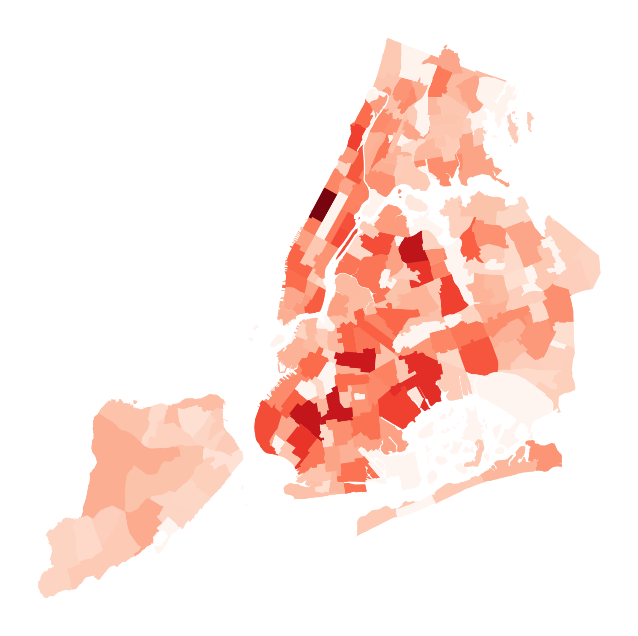

In [60]:
f, ax = plt.subplots(1,1,figsize=(8,8))

gdf_merged.plot(ax=ax, column = 'Population', cmap = 'Reds')
ax.axis('off')